# REHAB24 Conditioned TCN Training

This notebook is the next training branch after the exercise-specific-head experiment.

It keeps:
- REHAB24 only
- Camera17 only
- cleaned subset: `mocap_erroneous == 0`, `extra_person_in_cam17 <= 1`
- `classREHABV2` representation: `33 landmarks -> 32 frames -> 338 features`

It changes the model design:
- shared TCN backbone
- explicit exercise conditioning via an embedding
- one binary output head

The primary evaluation uses a global `0.5` threshold.
Per-exercise tuned thresholds are reported only as secondary diagnostics.

In [1]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [2]:
EXERCISE_NAMES = {
    1: "Arm Abduction",
    2: "Arm VW",
    3: "Push-ups",
    4: "Leg Abduction",
    5: "Leg Lunge",
    6: "Squats",
}

TEST_SUBJECTS = [2, 8]
VAL_SUBJECTS = [3, 4]

BATCH_SIZE = 32
EPOCHS = 80
LR = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT = 0.50
PATIENCE = 10
EX_EMBED_DIM = 16

USE_AUGMENTATION = True
NOISE_STD = 0.02
FEATURE_DROPOUT_P = 0.03
TEMPORAL_MASK_P = 0.20
MAX_SHIFT = 2

DATA_DIR = Path("../artifacts/artifacts_rehab24_fullreps_F32")
OUT_DIR = Path("../artifacts/conditioned_tcn_Final")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("OUT_DIR:", OUT_DIR.resolve())
print("TEST_SUBJECTS:", TEST_SUBJECTS)
print("VAL_SUBJECTS:", VAL_SUBJECTS)

DATA_DIR: ..\artifacts\artifacts_rehab24_fullreps_F32
OUT_DIR: C:\Users\nadaf\Desktop\RehabClass\classRehabV2\artifacts\conditioned_tcn_Final
TEST_SUBJECTS: [2, 8]
VAL_SUBJECTS: [3, 4]


In [3]:
X_pose = np.load(DATA_DIR / "X_pose.npy")
X_angles = np.load(DATA_DIR / "X_angles.npy")
y = np.load(DATA_DIR / "y.npy").astype(np.int64)
index_df = pd.read_csv(DATA_DIR / "index_clean.csv")

mask_clean = (
    (index_df["mocap_erroneous"].astype(int) == 0) &
    (index_df["extra_person_in_cam17"].astype(int) <= 1)
)

X_pose = X_pose[mask_clean.to_numpy()]
X_angles = X_angles[mask_clean.to_numpy()]
y = y[mask_clean.to_numpy()]
index_df = index_df.loc[mask_clean].reset_index(drop=True)

X_pose_flat = X_pose.reshape(X_pose.shape[0], X_pose.shape[1], -1)
X_all = np.concatenate([X_pose_flat, X_angles], axis=-1).astype(np.float32)

test_mask = index_df["person_id"].isin(TEST_SUBJECTS).to_numpy()
val_mask = index_df["person_id"].isin(VAL_SUBJECTS).to_numpy()
train_mask = ~(test_mask | val_mask)

X_train = X_all[train_mask]
X_val = X_all[val_mask]
X_test = X_all[test_mask]

y_train = y[train_mask]
y_val = y[val_mask]
y_test = y[test_mask]

idx_train = index_df.loc[train_mask].reset_index(drop=True)
idx_val = index_df.loc[val_mask].reset_index(drop=True)
idx_test = index_df.loc[test_mask].reset_index(drop=True)

train_subjects = sorted(idx_train["person_id"].unique().tolist())

print("Clean subset:", len(index_df))
print("Train subjects:", train_subjects)
print("Val subjects:", sorted(idx_val["person_id"].unique().tolist()))
print("Test subjects:", sorted(idx_test["person_id"].unique().tolist()))
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

print("\nValidation per exercise/class:")
print(idx_val.groupby(["exercise_id", "correctness"]).size().unstack(fill_value=0).reindex(range(1,7), fill_value=0))
print("\nTest per exercise/class:")
print(idx_test.groupby(["exercise_id", "correctness"]).size().unstack(fill_value=0).reindex(range(1,7), fill_value=0))

train_mean = X_train.reshape(-1, X_train.shape[-1]).mean(axis=0, keepdims=True)
train_std = X_train.reshape(-1, X_train.shape[-1]).std(axis=0, keepdims=True)
train_std = np.maximum(train_std, 1e-6)

def standardize(X, mean, std):
    return ((X - mean) / std).astype(np.float32)

X_train = standardize(X_train, train_mean, train_std)
X_val = standardize(X_val, train_mean, train_std)
X_test = standardize(X_test, train_mean, train_std)

Clean subset: 793
Train subjects: [1, 5, 6, 7, 9, 10]
Val subjects: [3, 4]
Test subjects: [2, 8]
Train: (415, 32, 338) Val: (197, 32, 338) Test: (181, 32, 338)

Validation per exercise/class:
correctness   0   1
exercise_id        
1            19  18
2            17  20
3             8   7
4            19  19
5            26  10
6            12  22

Test per exercise/class:
correctness   0   1
exercise_id        
1            15  20
2            28   8
3             4   9
4            17  23
5            15  15
6             3  24


In [4]:
class ConditionedDataset(Dataset):
    def __init__(
        self,
        X,
        y,
        exercise_ids,
        augment=False,
        noise_std=0.02,
        feature_dropout_p=0.03,
        temporal_mask_p=0.20,
        max_shift=2,
    ):
        self.X = np.asarray(X, dtype=np.float32)
        self.y = np.asarray(y, dtype=np.float32)
        self.exercise_ids = np.asarray(exercise_ids, dtype=np.int64)
        self.augment = bool(augment)
        self.noise_std = float(noise_std)
        self.feature_dropout_p = float(feature_dropout_p)
        self.temporal_mask_p = float(temporal_mask_p)
        self.max_shift = int(max_shift)

    def __len__(self):
        return len(self.X)

    def _augment(self, x):
        x = x.copy()
        if self.max_shift > 0:
            shift = np.random.randint(-self.max_shift, self.max_shift + 1)
            if shift != 0:
                x = np.roll(x, shift=shift, axis=0)
        if self.noise_std > 0:
            x = x + np.random.normal(0.0, self.noise_std, size=x.shape).astype(np.float32)
        if self.feature_dropout_p > 0:
            feat_mask = (np.random.rand(1, x.shape[1]) > self.feature_dropout_p).astype(np.float32)
            x = x * feat_mask
        if self.temporal_mask_p > 0 and np.random.rand() < self.temporal_mask_p:
            T = x.shape[0]
            mask_len = max(1, T // 8)
            start = np.random.randint(0, max(1, T - mask_len + 1))
            x[start:start + mask_len] = 0.0
        return x.astype(np.float32)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.augment:
            x = self._augment(x)
        x = torch.tensor(x.transpose(1, 0), dtype=torch.float32)
        y = torch.tensor(float(self.y[idx]), dtype=torch.float32)
        ex = torch.tensor(int(self.exercise_ids[idx] - 1), dtype=torch.long)
        return x, y, ex


train_ex = idx_train["exercise_id"].to_numpy(dtype=np.int64)
val_ex = idx_val["exercise_id"].to_numpy(dtype=np.int64)
test_ex = idx_test["exercise_id"].to_numpy(dtype=np.int64)

group_counts = idx_train.groupby(["exercise_id", "correctness"]).size().to_dict()
sample_weights = np.array(
    [1.0 / group_counts[(int(ex), int(label))] for ex, label in zip(train_ex, y_train)],
    dtype=np.float64,
)

train_ds = ConditionedDataset(
    X_train, y_train, train_ex,
    augment=USE_AUGMENTATION,
    noise_std=NOISE_STD,
    feature_dropout_p=FEATURE_DROPOUT_P,
    temporal_mask_p=TEMPORAL_MASK_P,
    max_shift=MAX_SHIFT,
)
val_ds = ConditionedDataset(X_val, y_val, val_ex, augment=False)
test_ds = ConditionedDataset(X_test, y_test, test_ex, augment=False)

train_sampler = WeightedRandomSampler(
    weights=torch.as_tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True,
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print("Train groups:")
print(idx_train.groupby(["exercise_id", "correctness"]).size().unstack(fill_value=0).reindex(range(1,7), fill_value=0))

Train groups:
correctness   0   1
exercise_id        
1            35  43
2            46  43
3            20  17
4            13  35
5            33  35
6            36  59


In [5]:
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x if self.chomp_size == 0 else x[:, :, :-self.chomp_size]


class ResidualTCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, dilation=1, dropout=0.5):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Conv1d(out_ch, out_ch, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )
        self.downsample = nn.Conv1d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()
        self.out_relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.net(x)
        res = self.downsample(x)
        return self.out_relu(out + res)


class ConditionedTCN(nn.Module):
    def __init__(self, input_dim, num_exercises=6, ex_embed_dim=16, dropout=0.5):
        super().__init__()
        self.exercise_embedding = nn.Embedding(num_exercises, ex_embed_dim)
        self.backbone = nn.Sequential(
            ResidualTCNBlock(input_dim + ex_embed_dim, 64, kernel_size=3, dilation=1, dropout=dropout),
            ResidualTCNBlock(64, 64, kernel_size=3, dilation=2, dropout=dropout),
            ResidualTCNBlock(64, 96, kernel_size=3, dilation=4, dropout=dropout),
            ResidualTCNBlock(96, 96, kernel_size=3, dilation=8, dropout=dropout),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(96, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x, exercise_idx):
        T = x.shape[-1]
        ex_emb = self.exercise_embedding(exercise_idx).unsqueeze(-1).expand(-1, -1, T)
        x = torch.cat([x, ex_emb], dim=1)
        feats = self.backbone(x)
        pooled = self.pool(feats)
        logits = self.head(pooled).squeeze(-1)
        return logits


input_dim = X_train.shape[-1]
model = ConditionedTCN(
    input_dim=input_dim,
    num_exercises=6,
    ex_embed_dim=EX_EMBED_DIM,
    dropout=DROPOUT,
).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

exercise_pos_weight = {}
for ex_id in range(1, 7):
    sub = idx_train[idx_train["exercise_id"] == ex_id]
    pos = max(1, int((sub["correctness"] == 1).sum()))
    neg = max(1, int((sub["correctness"] == 0).sum()))
    exercise_pos_weight[ex_id - 1] = float(neg / pos)

print("input_dim:", input_dim)
print("exercise_pos_weight:", exercise_pos_weight)
print("params:", sum(p.numel() for p in model.parameters()))

input_dim: 338
exercise_pos_weight: {0: 0.813953488372093, 1: 1.069767441860465, 2: 1.1764705882352942, 3: 0.37142857142857144, 4: 0.9428571428571428, 5: 0.6101694915254238}
params: 243457


In [6]:
def batch_loss(logits, y_true, exercise_idx):
    base = F.binary_cross_entropy_with_logits(logits, y_true, reduction="none")
    pos_w = torch.tensor(
        [exercise_pos_weight[int(ex.item())] for ex in exercise_idx],
        device=logits.device,
        dtype=torch.float32,
    )
    weights = torch.where(y_true > 0.5, pos_w, torch.ones_like(pos_w))
    return (base * weights).mean()


def collect_predictions(model, loader):
    model.eval()
    rows = []
    total_loss = 0.0
    total_n = 0
    with torch.no_grad():
        for x, y_true, ex_idx in loader:
            x = x.to(DEVICE)
            y_true = y_true.to(DEVICE)
            ex_idx = ex_idx.to(DEVICE)

            logits = model(x, ex_idx)
            loss = batch_loss(logits, y_true, ex_idx)
            probs = torch.sigmoid(logits).detach().cpu().numpy()
            total_loss += float(loss.item()) * len(probs)
            total_n += len(probs)

            for yy, pp, ll, ee in zip(
                y_true.detach().cpu().numpy(),
                probs,
                logits.detach().cpu().numpy(),
                ex_idx.detach().cpu().numpy(),
            ):
                rows.append({
                    "correctness": int(yy),
                    "prob_correct": float(pp),
                    "logit": float(ll),
                    "exercise_idx0": int(ee),
                    "exercise_id": int(ee) + 1,
                    "exercise_name": EXERCISE_NAMES[int(ee) + 1],
                })
    return pd.DataFrame(rows), total_loss / max(total_n, 1)


def apply_global_threshold(df, threshold=0.5):
    out = df.copy()
    out["threshold"] = float(threshold)
    out["pred"] = (out["prob_correct"] >= threshold).astype(int)
    return out


def tune_thresholds(df):
    thresholds = {}
    for ex_id in range(1, 7):
        sub = df[df["exercise_id"] == ex_id].copy()
        if sub.empty or sub["correctness"].nunique() < 2:
            thresholds[ex_id] = 0.5
            continue
        best_thr = 0.5
        best_f1 = -1.0
        for thr in np.linspace(0.2, 0.8, 25):
            pred = (sub["prob_correct"].to_numpy() >= thr).astype(int)
            f1 = f1_score(sub["correctness"], pred, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_thr = float(thr)
        thresholds[ex_id] = best_thr
    return thresholds


def apply_tuned_thresholds(df, thresholds):
    out = df.copy()
    out["threshold"] = out["exercise_id"].map(thresholds).astype(float)
    out["pred"] = (out["prob_correct"] >= out["threshold"]).astype(int)
    return out


def evaluate_df(df_pred):
    overall = {
        "accuracy": float(accuracy_score(df_pred["correctness"], df_pred["pred"])),
        "macro_f1": float(f1_score(df_pred["correctness"], df_pred["pred"], average="macro", zero_division=0)),
    }
    per_ex_rows = []
    for ex_id in range(1, 7):
        sub = df_pred[df_pred["exercise_id"] == ex_id].copy()
        if sub.empty:
            continue
        per_ex_rows.append({
            "exercise_id": ex_id,
            "exercise_name": EXERCISE_NAMES[ex_id],
            "n": int(len(sub)),
            "accuracy": float(accuracy_score(sub["correctness"], sub["pred"])),
            "f1": float(f1_score(sub["correctness"], sub["pred"], zero_division=0)),
            "threshold": float(sub["threshold"].iloc[0]),
            "n_incorrect": int((sub["correctness"] == 0).sum()),
            "n_correct": int((sub["correctness"] == 1).sum()),
        })
    return overall, pd.DataFrame(per_ex_rows)


history = []
best_state = None
best_epoch = -1
best_val_f1 = -1.0
best_tuned_thresholds = None
patience_left = PATIENCE

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss_sum = 0.0
    train_n = 0

    for x, y_true, ex_idx in train_loader:
        x = x.to(DEVICE)
        y_true = y_true.to(DEVICE)
        ex_idx = ex_idx.to(DEVICE)

        optimizer.zero_grad()
        logits = model(x, ex_idx)
        loss = batch_loss(logits, y_true, ex_idx)
        loss.backward()
        optimizer.step()

        train_loss_sum += float(loss.item()) * len(y_true)
        train_n += len(y_true)

    train_loss = train_loss_sum / max(train_n, 1)

    val_df, val_loss = collect_predictions(model, val_loader)
    val_global = apply_global_threshold(val_df, threshold=0.5)
    val_global_metrics, _ = evaluate_df(val_global)
    tuned_thresholds = tune_thresholds(val_df)
    val_tuned = apply_tuned_thresholds(val_df, tuned_thresholds)
    val_tuned_metrics, _ = evaluate_df(val_tuned)

    scheduler.step(val_global_metrics["macro_f1"])

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_accuracy_global": val_global_metrics["accuracy"],
        "val_macro_f1_global": val_global_metrics["macro_f1"],
        "val_accuracy_tuned": val_tuned_metrics["accuracy"],
        "val_macro_f1_tuned": val_tuned_metrics["macro_f1"],
        **{f"thr_ex{ex_id}": tuned_thresholds[ex_id] for ex_id in range(1, 7)},
    })

    print(
        f"epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"val_f1_global={val_global_metrics['macro_f1']:.4f} | "
        f"val_f1_tuned={val_tuned_metrics['macro_f1']:.4f}"
    )

    if val_global_metrics["macro_f1"] > best_val_f1:
        best_val_f1 = val_global_metrics["macro_f1"]
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        best_tuned_thresholds = tuned_thresholds.copy()
        patience_left = PATIENCE
    else:
        patience_left -= 1
        if patience_left <= 0:
            print("Early stopping.")
            break

if best_state is None:
    raise RuntimeError("Training did not produce a best checkpoint.")

model.load_state_dict(best_state)
history_df = pd.DataFrame(history)
print("Best epoch:", best_epoch)
print("Best val macro F1 (global 0.5):", best_val_f1)
print("Best tuned thresholds:", best_tuned_thresholds)

epoch 01 | train_loss=0.6196 | val_loss=0.6032 | val_f1_global=0.5248 | val_f1_tuned=0.6042
epoch 02 | train_loss=0.5800 | val_loss=0.6003 | val_f1_global=0.5310 | val_f1_tuned=0.5563
epoch 03 | train_loss=0.5316 | val_loss=0.5862 | val_f1_global=0.5867 | val_f1_tuned=0.6498
epoch 04 | train_loss=0.5254 | val_loss=0.6056 | val_f1_global=0.5072 | val_f1_tuned=0.6542
epoch 05 | train_loss=0.5146 | val_loss=0.8413 | val_f1_global=0.5769 | val_f1_tuned=0.5832
epoch 06 | train_loss=0.4775 | val_loss=0.6303 | val_f1_global=0.5674 | val_f1_tuned=0.6622
epoch 07 | train_loss=0.4027 | val_loss=0.9896 | val_f1_global=0.5416 | val_f1_tuned=0.5969
epoch 08 | train_loss=0.3620 | val_loss=1.0903 | val_f1_global=0.5492 | val_f1_tuned=0.5638
epoch 09 | train_loss=0.3633 | val_loss=1.0621 | val_f1_global=0.5596 | val_f1_tuned=0.6207
epoch 10 | train_loss=0.3086 | val_loss=0.9061 | val_f1_global=0.6074 | val_f1_tuned=0.6527
epoch 11 | train_loss=0.2667 | val_loss=0.8218 | val_f1_global=0.6435 | val_f1_t

In [7]:
val_pred_raw, val_loss = collect_predictions(model, val_loader)
val_pred_global = apply_global_threshold(val_pred_raw, threshold=0.5)
val_global_metrics, val_per_ex_global = evaluate_df(val_pred_global)
val_pred_tuned = apply_tuned_thresholds(val_pred_raw, best_tuned_thresholds)
val_tuned_metrics, val_per_ex_tuned = evaluate_df(val_pred_tuned)

test_pred_raw, test_loss = collect_predictions(model, test_loader)
test_pred_global = apply_global_threshold(test_pred_raw, threshold=0.5)
test_global_metrics, test_per_ex_global = evaluate_df(test_pred_global)
test_pred_tuned = apply_tuned_thresholds(test_pred_raw, best_tuned_thresholds)
test_tuned_metrics, test_per_ex_tuned = evaluate_df(test_pred_tuned)

print("Validation global metrics:", val_global_metrics)
print("Validation tuned metrics:", val_tuned_metrics)
print("Test global metrics:", test_global_metrics)
print("Test tuned metrics:", test_tuned_metrics)

print("\nPer-exercise test metrics (global 0.5):")
display(test_per_ex_global)

print("\nPer-exercise test metrics (tuned):")
display(test_per_ex_tuned)

print("\nTest classification report (global 0.5):")
print(classification_report(test_pred_global["correctness"], test_pred_global["pred"], digits=4, zero_division=0))
print("Confusion matrix (global 0.5):")
print(confusion_matrix(test_pred_global["correctness"], test_pred_global["pred"]))

Validation global metrics: {'accuracy': 0.7461928934010152, 'macro_f1': 0.7420385501780851}
Validation tuned metrics: {'accuracy': 0.7817258883248731, 'macro_f1': 0.7794527324325028}
Test global metrics: {'accuracy': 0.8011049723756906, 'macro_f1': 0.8010989010989011}
Test tuned metrics: {'accuracy': 0.7790055248618785, 'macro_f1': 0.7786744925409635}

Per-exercise test metrics (global 0.5):


,exercise_id,exercise_name,n,accuracy,f1,threshold,n_incorrect,n_correct
0,1,Arm Abduction,35,0.971429,0.974359,0.5,15,20
1,2,Arm VW,36,0.888889,0.750000,0.5,28,8
2,3,Push-ups,13,0.923077,0.947368,0.5,4,9
3,4,Leg Abduction,40,0.675000,0.723404,0.5,17,23
4,5,Leg Lunge,30,0.566667,0.235294,0.5,15,15
5,6,Squats,27,0.851852,0.909091,0.5,3,24



Per-exercise test metrics (tuned):


,exercise_id,exercise_name,n,accuracy,f1,threshold,n_incorrect,n_correct
0,1,Arm Abduction,35,0.971429,0.974359,0.400,15,20
1,2,Arm VW,36,0.805556,0.222222,0.775,28,8
2,3,Push-ups,13,0.923077,0.947368,0.500,4,9
3,4,Leg Abduction,40,0.675000,0.723404,0.550,17,23
4,5,Leg Lunge,30,0.533333,0.125000,0.525,15,15
5,6,Squats,27,0.851852,0.909091,0.275,3,24



Test classification report (global 0.5):
              precision    recall  f1-score   support

           0     0.7347    0.8780    0.8000        82
           1     0.8795    0.7374    0.8022        99

    accuracy                         0.8011       181
   macro avg     0.8071    0.8077    0.8011       181
weighted avg     0.8139    0.8011    0.8012       181

Confusion matrix (global 0.5):
[[72 10]
 [26 73]]


In [9]:
best_ckpt_path = OUT_DIR / "best_conditioned_tcn_clean.pt"
history_path = OUT_DIR / "history.csv"
val_global_path = OUT_DIR / "val_predictions_global.csv"
val_tuned_path = OUT_DIR / "val_predictions_tuned.csv"
test_global_path = OUT_DIR / "test_predictions_global.csv"
test_tuned_path = OUT_DIR / "test_predictions_tuned.csv"
test_per_ex_global_path = OUT_DIR / "test_per_exercise_global.csv"
test_per_ex_tuned_path = OUT_DIR / "test_per_exercise_tuned.csv"
report_path = OUT_DIR / "training_report.json"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "train_mean": train_mean.astype(np.float32),
        "train_std": train_std.astype(np.float32),
        "input_dim": int(input_dim),
        "exercise_names": EXERCISE_NAMES,
        "global_threshold": 0.5,
        "tuned_thresholds": best_tuned_thresholds,
        "exercise_embedding_dim": EX_EMBED_DIM,
        "test_subjects": TEST_SUBJECTS,
        "val_subjects": VAL_SUBJECTS,
        "train_subjects": train_subjects,
    },
    best_ckpt_path,
)

history_df.to_csv(history_path, index=False)
val_pred_global.to_csv(val_global_path, index=False)
val_pred_tuned.to_csv(val_tuned_path, index=False)
test_pred_global.to_csv(test_global_path, index=False)
test_pred_tuned.to_csv(test_tuned_path, index=False)
test_per_ex_global.to_csv(test_per_ex_global_path, index=False)
test_per_ex_tuned.to_csv(test_per_ex_tuned_path, index=False)

report = {
    "best_epoch": int(best_epoch),
    "best_val_macro_f1_global": float(best_val_f1),
    "val_metrics_global": val_global_metrics,
    "val_metrics_tuned": val_tuned_metrics,
    "test_metrics_global": test_global_metrics,
    "test_metrics_tuned": test_tuned_metrics,
    "global_threshold": 0.5,
    "tuned_thresholds": {str(k): float(v) for k, v in best_tuned_thresholds.items()},
    "n_train": int(len(idx_train)),
    "n_val": int(len(idx_val)),
    "n_test": int(len(idx_test)),
    "train_subjects": train_subjects,
    "val_subjects": VAL_SUBJECTS,
    "test_subjects": TEST_SUBJECTS,
    "filter_policy": {
        "mocap_erroneous": 0,
        "extra_person_in_cam17_max": 1,
    },
}
with open(report_path, "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2)

print("Saved:", best_ckpt_path.resolve())
print("Saved:", history_path.resolve())
print("Saved:", val_global_path.resolve())
print("Saved:", val_tuned_path.resolve())
print("Saved:", test_global_path.resolve())
print("Saved:", test_tuned_path.resolve())
print("Saved:", test_per_ex_global_path.resolve())
print("Saved:", test_per_ex_tuned_path.resolve())
print("Saved:", report_path.resolve())

Saved: C:\Users\nadaf\Desktop\RehabClass\classRehabV2\artifacts\conditioned_tcn_Final\best_conditioned_tcn_clean.pt
Saved: C:\Users\nadaf\Desktop\RehabClass\classRehabV2\artifacts\conditioned_tcn_Final\history.csv
Saved: C:\Users\nadaf\Desktop\RehabClass\classRehabV2\artifacts\conditioned_tcn_Final\val_predictions_global.csv
Saved: C:\Users\nadaf\Desktop\RehabClass\classRehabV2\artifacts\conditioned_tcn_Final\val_predictions_tuned.csv
Saved: C:\Users\nadaf\Desktop\RehabClass\classRehabV2\artifacts\conditioned_tcn_Final\test_predictions_global.csv
Saved: C:\Users\nadaf\Desktop\RehabClass\classRehabV2\artifacts\conditioned_tcn_Final\test_predictions_tuned.csv
Saved: C:\Users\nadaf\Desktop\RehabClass\classRehabV2\artifacts\conditioned_tcn_Final\test_per_exercise_global.csv
Saved: C:\Users\nadaf\Desktop\RehabClass\classRehabV2\artifacts\conditioned_tcn_Final\test_per_exercise_tuned.csv
Saved: C:\Users\nadaf\Desktop\RehabClass\classRehabV2\artifacts\conditioned_tcn_Final\training_report.jso

In [10]:
history_df.tail(10)

,epoch,train_loss,val_loss,val_accuracy_global,val_macro_f1_global,val_accuracy_tuned,val_macro_f1_tuned,thr_ex1,thr_ex2,thr_ex3,thr_ex4,thr_ex5,thr_ex6
12,13,0.253875,0.976835,0.649746,0.631356,0.766497,0.762027,0.775,0.725,0.200,0.475,0.800,0.650
13,14,0.201320,1.280701,0.583756,0.551278,0.680203,0.658184,0.800,0.200,0.200,0.300,0.775,0.775
14,15,0.210826,0.950516,0.680203,0.673609,0.725888,0.713478,0.200,0.300,0.200,0.275,0.700,0.300
15,16,0.157913,0.972341,0.690355,0.678389,0.751269,0.742676,0.800,0.225,0.450,0.250,0.700,0.350
16,17,0.154964,1.102232,0.700508,0.686246,0.756345,0.750948,0.750,0.675,0.700,0.575,0.550,0.725
17,18,0.156697,1.140749,0.685279,0.673771,0.741117,0.734101,0.650,0.800,0.250,0.675,0.375,0.800
18,19,0.172185,1.158304,0.690355,0.680849,0.730964,0.725417,0.375,0.650,0.725,0.675,0.225,0.675
19,20,0.134213,1.191050,0.695431,0.688685,0.736041,0.731720,0.725,0.800,0.550,0.700,0.200,0.200
20,21,0.165874,1.154773,0.690355,0.679658,0.746193,0.740571,0.800,0.775,0.450,0.750,0.225,0.200
21,22,0.115273,1.114054,0.705584,0.698108,0.751269,0.746860,0.775,0.575,0.450,0.800,0.200,0.200


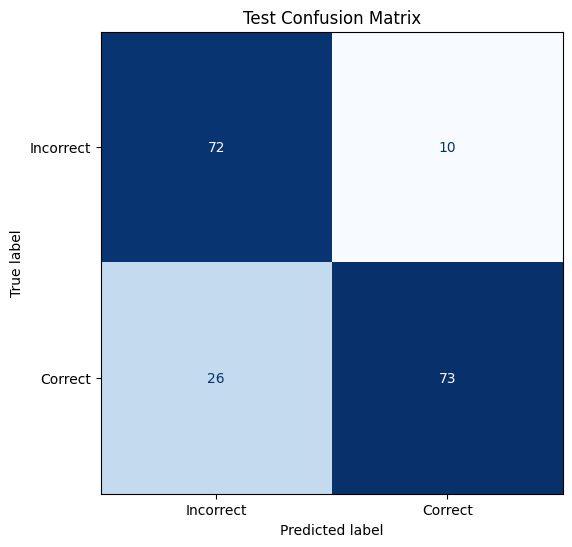

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    test_pred_global["correctness"],
    test_pred_global["pred"]
)

fig, ax = plt.subplots(figsize=(6,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Incorrect", "Correct"]
)

disp.plot(ax=ax, cmap="Blues", colorbar=False)

plt.title("Test Confusion Matrix")
plt.show()

In [12]:
global_acc = (
    test_pred_global["correctness"] ==
    test_pred_global["pred"]
).mean()

print(f"Global Test Accuracy: {global_acc:.4f}")

Global Test Accuracy: 0.8011


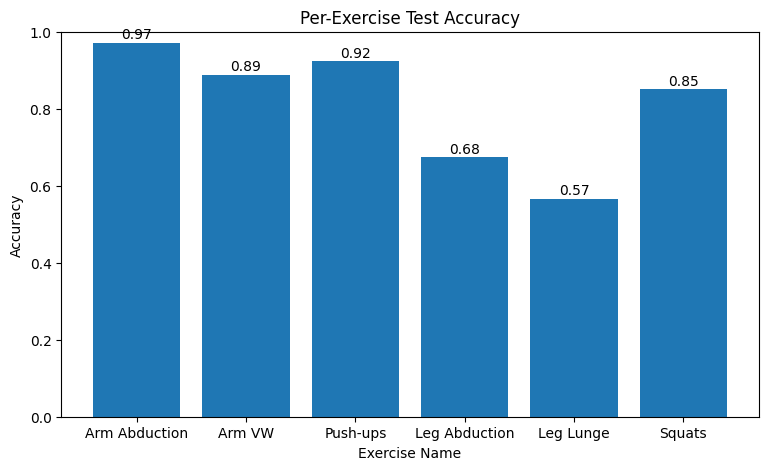

In [13]:
plt.figure(figsize=(9,5))

bars = plt.bar(
    test_per_ex_global["exercise_name"],
    test_per_ex_global["accuracy"]
)

plt.ylim(0, 1)

plt.xlabel("Exercise Name")
plt.ylabel("Accuracy")
plt.title("Per-Exercise Test Accuracy")

plt.xticks(test_per_ex_global["exercise_name"])

for bar, acc in zip(bars, test_per_ex_global["accuracy"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        acc + 0.01,
        f"{acc:.2f}",
        ha='center'
    )

plt.show()